Name - Sandesh Arun Mohite

Roll_NO - 23

Division - AIML(A)


## Logistic Regression for Binary Classification:


## Objective
To implement Logistic Regression for a binary classification problem (Placed / Not Placed)
using CGPA and IQ as input features.


## Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


## Step 2: Load Dataset

In [ ]:
# Load the Placement dataset from the specified file path into a Pandas DataFrame
df = pd.read_csv("/content/drive/MyDrive/Placement_Y_N.csv")

In [ ]:
# Display the first five rows of the DataFrame to quickly inspect the data
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


## Step 3: Data Cleaning

In [ ]:
# Remove the unnecessary index column ('Unnamed: 0') from the DataFrame
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [ ]:
# Display concise information about the DataFrame such as column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
# Check for missing (null) values in each column of the DataFrame
df.isnull().sum()

,0
cgpa,0
iq,0
placement,0


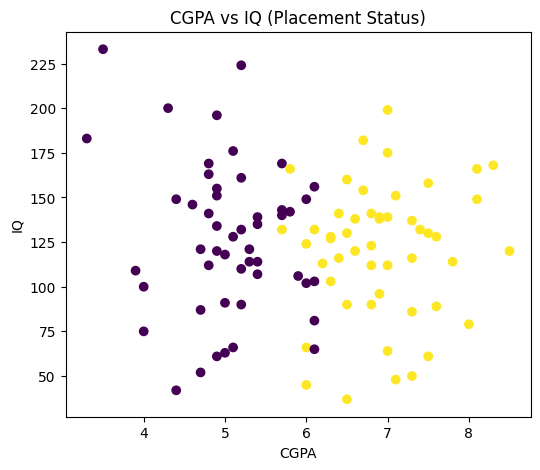

In [ ]:
# Create a scatter plot of CGPA vs IQ
# Color points based on placement status (0 = Not Placed, 1 = Placed)

plt.figure(figsize=(6, 5))
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ (Placement Status)')
plt.show()


## Step 4: Feature Selection

In [ ]:
# Select the independent variables (features): CGPA and IQ
X = df[['cgpa', 'iq']]

# Select the dependent variable (target): Placement status (1 = Placed, 0 = Not Placed)
y = df['placement']


## Step 5: Train-Test Split

In [ ]:
# Split the dataset into training and testing sets
# 80% data is used for training and 20% for testing
# stratify=y ensures both classes are equally represented in train and test sets
# random_state ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 6: Feature Scaling

In [ ]:
# Create a StandardScaler object to normalize the feature values
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# This standardizes features to have mean = 0 and standard deviation = 1
X_train = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
# (Important: do NOT fit again on test data)
X_test = scaler.transform(X_test)

## Step 7: Model Training

In [ ]:
# Create an object of the Logistic Regression model
model = LogisticRegression()


In [ ]:
# Train (fit) the model using the training data
# The model learns the relationship between CGPA, IQ and placement outcome
model.fit(X_train, y_train)

LogisticRegression()

## Step 8: Predictions

In [ ]:
# Predict the placement outcome for the test dataset using the trained model
y_pred = model.predict(X_test)

## Step 9: Model Evaluation

In [ ]:
# Display the accuracy of the model
# Accuracy shows the percentage of correctly classified instances
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


In [ ]:
# Display the confusion matrix
# It shows counts of True Positives, True Negatives, False Positives, and False Negatives
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[9 1]
 [2 8]]


In [ ]:
# Display the classification report
# It includes precision, recall, F1-score, and support for each class
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



## Step 10: ROC Curve

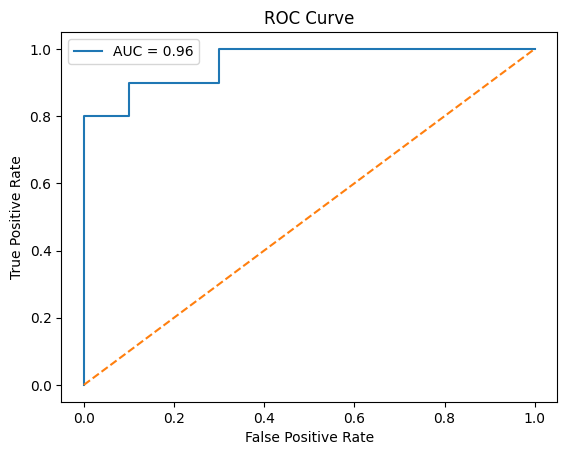

In [ ]:
# Predict the probability of the positive class (Placed = 1) for the test data
# [:, 1] selects the probability of class '1'
y_prob = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR) for different thresholds
fpr, tpr, _ = roc_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label='AUC = %.2f' % roc_auc)

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')

# Label the axes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Set the title of the plot
plt.title('ROC Curve')

# Display legend
plt.legend()

# Show the plot
plt.show()


## Step 11: Prediction for New Data

In [ ]:
# Create a new data point for a student with CGPA = 7.8 and IQ = 120
new_student = np.array([[7.8, 120]])

# Apply the same scaling used for training data
new_student_scaled = scaler.transform(new_student)

# Predict the placement outcome for the new student
prediction = model.predict(new_student_scaled)

# Display the prediction result in a readable format
print("Prediction:", "Placed" if prediction[0] == 1 else "Not Placed")

Prediction: Placed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Take input values from the user
cgpa = float(input("Enter CGPA: "))
iq = float(input("Enter IQ: "))

# Create input array in required 2D format
new_student = np.array([[cgpa, iq]])

# Apply the same scaling used during model training
new_student_scaled = scaler.transform(new_student)

# Predict the placement outcome for the given input
prediction = model.predict(new_student_scaled)

# Display the prediction result in a user-friendly format
print("Prediction:", "Placed" if prediction[0] == 1 else "Not Placed")

Enter CGPA: 8
Enter IQ: 80
Prediction: Placed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

In [ ]:
pickle.dump(model,open('BCModel.pkl','wb'))

**Flask Code**

save this file as 'app.py'

In [ ]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load Trained Logistic Regression Model
model = pickle.load(open("BCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read user inputs
    cgpa = float(request.form['cgpa'])
    iq = float(request.form['iq'])

    # Prediction
    prediction = model.predict(np.array([[cgpa, iq]]))

    # Convert numeric prediction to text
    if prediction[0] == 1:
        result = "Student is Likely to be PLACED"
    else:
        result = "Student is NOT Likely to be PLACED"

    return render_template(
        "index.html",
        prediction_text=result
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file as 'index.html'

In [ ]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Placement Prediction</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{

    background:#eef4ff;
    display:flex;
    justify-content:center;
    align-items:center;
    height:100vh;

}

.container{

    width:430px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 8px 20px rgba(0,0,0,.2);

}

h1{

    text-align:center;
    color:#1565c0;

}

h3{

    text-align:center;
    color:#666;
    margin-top:8px;
    margin-bottom:25px;

}

label{

    display:block;
    font-weight:bold;
    margin-top:15px;
    margin-bottom:6px;

}

input{

    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;

}

button{

    width:100%;
    padding:13px;
    margin-top:25px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;

}

button:hover{

    background:#0d47a1;

}

.result{

    margin-top:25px;
    padding:18px;
    border-radius:8px;
    text-align:center;
    font-size:22px;
    font-weight:bold;
    background:#e8f5e9;
    color:green;

}

footer{

    margin-top:20px;
    text-align:center;
    color:#777;
    font-size:13px;

}

</style>

</head>

<body>

<div class="container">

<h1>Placement Prediction System</h1>

<h3>Binary Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Enter Student CGPA</label>

<input
type="number"
name="cgpa"
step="0.01"
min="0"
max="10"
placeholder="Example : 8.25"
required>

<label>Enter IQ Score</label>

<input
type="number"
name="iq"
placeholder="Example : 120"
required>

<button type="submit">

Predict Placement

</button>

</form>

{% if prediction_text %}

<div class="result">

{{ prediction_text }}

</div>

{% endif %}

<footer>

By Dr. Sachin Balawant Takmare

</footer>

</div>

</body>

</html>

SyntaxError: invalid decimal literal (2657364888.py, line 26)